In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

BASE_DIR   = Path('..')
GOLD_DIR   = BASE_DIR / 'medallion' / 'gold'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

co = pd.read_parquet(GOLD_DIR / 'gold_customer_orders.parquet')
co = co[co['customer_id'] != '7888450879743'].copy()
co['processed_at'] = pd.to_datetime(co['processed_at'], utc=True)
co['year']  = co['processed_at'].dt.year
co['month'] = co['processed_at'].dt.to_period('M')

social_sources  = ['facebook','meta','ig','igshopping','tiktok','snowball','igpost','affiliate']
social_mediums  = ['paid_social','social','instagram_stories','referral_url','affiliate']
social_channels = ['TikTok','Affiliate']
is_social = (
    co['channel'].isin(social_channels) |
    co['utm_source'].str.lower().isin(social_sources) |
    co['utm_medium'].str.lower().isin(social_mediums)
)
co['channel_grouped'] = np.where(is_social, 'Social Referral', co['channel'])
target_channels = ['DTC', 'Lazada', 'Shopee', 'Social Referral']
co_target = co[co['channel_grouped'].isin(target_channels)].copy()

print('Data loaded.')

Data loaded.


/var/folders/9v/fsp31sdn6vd0t8_8bdxnldb80000gn/T/ipykernel_96814/3819217786.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  co['month'] = co['processed_at'].dt.to_period('M')


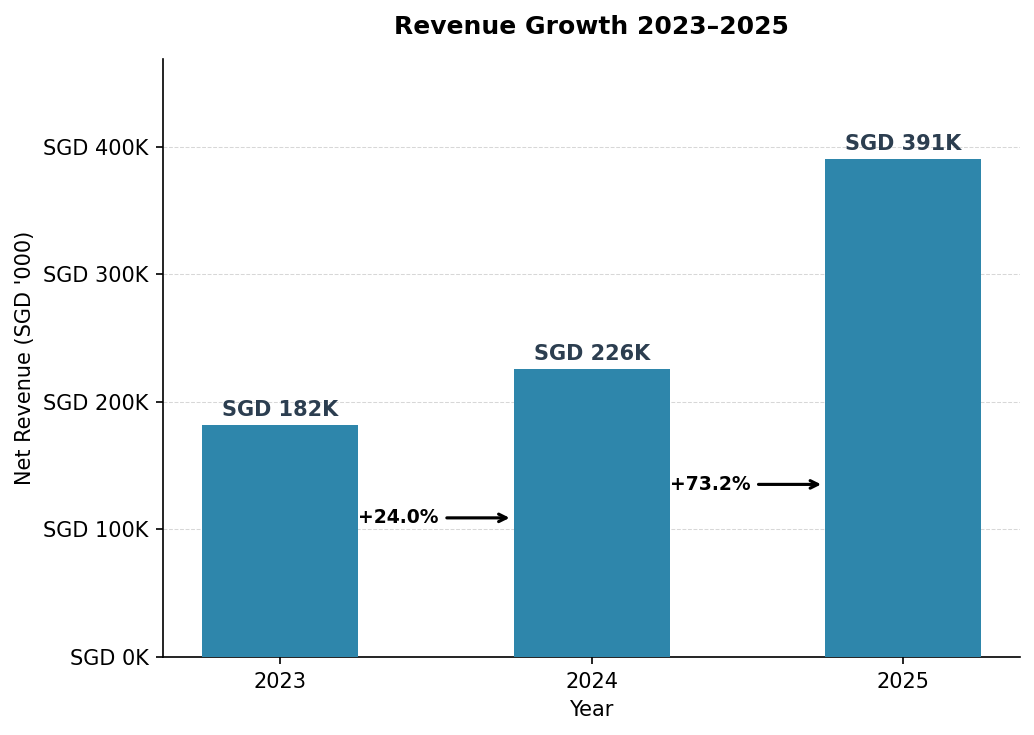

year
2023    181.84575
2024    225.56725
2025    390.61240
Name: price_total, dtype: float64


In [5]:
# ── Chart 1: Revenue Growth 2023-2025 ────────────────────────────────────────
# Paid orders only, exclude 'Other' channel (matrixify/migration import data)
rev_year = (
    co[
        (co['year'].isin([2023, 2024, 2025])) &
        (co['payment_status'] == 'paid') &
        (co['channel'] != 'Other')
    ]
    .groupby('year')['price_total']
    .sum()
    .div(1000)
)
years    = rev_year.index.tolist()
rev_vals = rev_year.values

yoy_growth = [None] + [
    (rev_vals[i] - rev_vals[i-1]) / rev_vals[i-1] * 100
    for i in range(1, len(rev_vals))
]

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

bars = ax.bar([str(y) for y in years], rev_vals, color='#2E86AB', width=0.5, zorder=3)

# Value labels on top of bars
for bar, val in zip(bars, rev_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        f'SGD {val:.0f}K',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50'
    )

# Growth annotations with arrows between bars
for i in range(1, len(years)):
    x0 = bars[i-1].get_x() + bars[i-1].get_width()
    x1 = bars[i].get_x()
    y0 = rev_vals[i-1] * 0.6
    ax.annotate(
        f'+{yoy_growth[i]:.1f}%',
        xy=(x1, y0), xytext=(x0, y0),
        fontsize=9, fontweight='bold', color='#000000',
        ha='left', va='center',
        arrowprops=dict(arrowstyle='->', color='#000000', lw=1.5)
    )

ax.set_title('Revenue Growth 2023–2025', fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel("Net Revenue (SGD '000)", fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'SGD {x:,.0f}K'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)
ax.set_ylim(0, max(rev_vals) * 1.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'business_context_revenue.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()
print(rev_year)

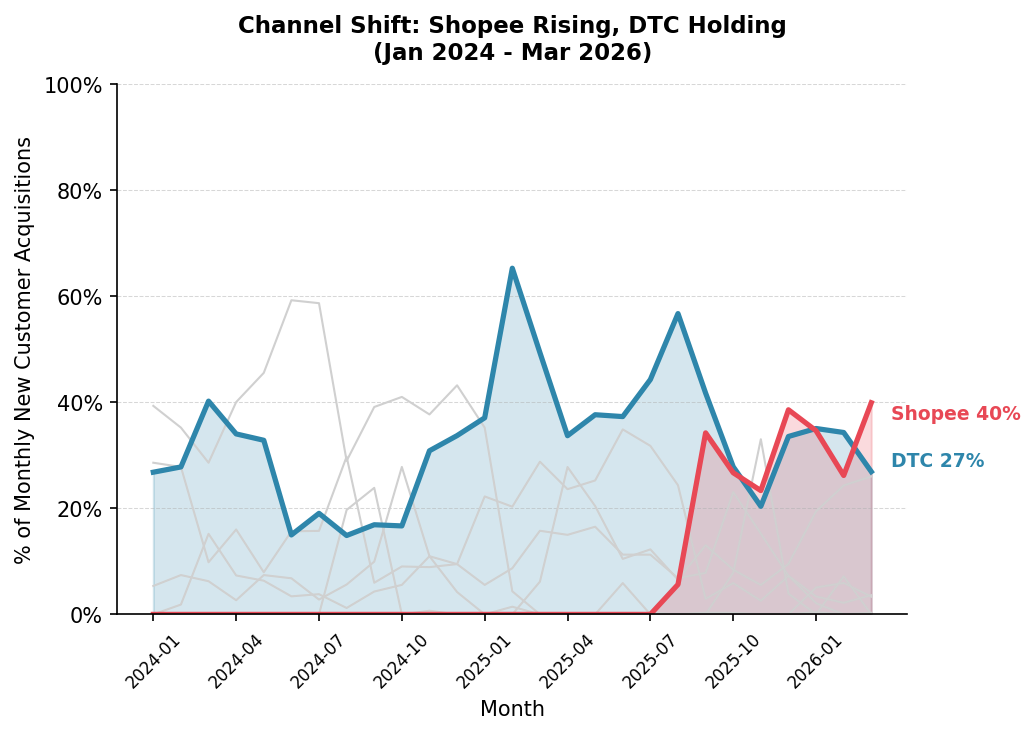

Mar 2026 — DTC: 26.9%  Shopee: 39.9%


In [4]:
# ── Chart 2: Channel Shift — Shopee Rising, DTC Holding ──────────────────────
# Denominator = ALL channels (most accurate match to original)
first_orders_all = co[co['order_sequence'] == 1].copy()
monthly_all = (
    first_orders_all
    .groupby(['month', 'channel_grouped'])
    .size()
    .unstack(fill_value=0)
)
monthly_all = monthly_all.loc[pd.Period('2024-01', 'M'):pd.Period('2026-03', 'M')]
monthly_pct = monthly_all.div(monthly_all.sum(axis=1), axis=0) * 100

x_labels  = [str(m) for m in monthly_all.index]
x_indices = np.arange(len(monthly_all))

dtc_pct    = monthly_pct.get('DTC',    pd.Series(0, index=monthly_all.index))
shopee_pct = monthly_pct.get('Shopee', pd.Series(0, index=monthly_all.index))

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# Other channels in grey
for ch in monthly_pct.columns:
    if ch not in ('DTC', 'Shopee'):
        ax.plot(x_indices, monthly_pct[ch], color='#D0D0D0', linewidth=1)

# DTC and Shopee highlighted
ax.fill_between(x_indices, dtc_pct,    alpha=0.2, color='#2E86AB')
ax.fill_between(x_indices, shopee_pct, alpha=0.2, color='#E84855')
ax.plot(x_indices, dtc_pct,    color='#2E86AB', linewidth=2.5)
ax.plot(x_indices, shopee_pct, color='#E84855', linewidth=2.5)

# End labels
ax.text(len(x_indices) - 0.3, dtc_pct.iloc[-1] + 1,
        f'DTC {dtc_pct.iloc[-1]:.0f}%', color='#2E86AB', fontsize=9, fontweight='bold')
ax.text(len(x_indices) - 0.3, shopee_pct.iloc[-1] - 3,
        f'Shopee {shopee_pct.iloc[-1]:.0f}%', color='#E84855', fontsize=9, fontweight='bold')

ax.set_title(
    'Channel Shift: Shopee Rising, DTC Holding\n(Jan 2024 - Mar 2026)',
    fontsize=11, fontweight='bold', pad=12
)
ax.set_ylabel('% of Monthly New Customer Acquisitions', fontsize=10)
ax.set_xlabel('Month', fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(x_indices[::3])
ax.set_xticklabels(x_labels[::3], rotation=45, fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'business_context_shopee.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

print(f"Mar 2026 — DTC: {dtc_pct.iloc[-1]:.1f}%  Shopee: {shopee_pct.iloc[-1]:.1f}%")